In [ ]:
import pandas as pd
from sklearn.datasets import fetch_openml

mnist = fetch_openml("mnist_784", as_frame=False)

In [ ]:
X, y = mnist.data, mnist.target

# split data
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

In [ ]:
import matplotlib.pyplot as plt


def plot_digit(image_data):
    # takes in one instance of image data and displays it
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

In [ ]:
y_train_5 = y_train == "5"
y_test_5 = y_test == "5"

In [7]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [ ]:
from sklearn.model_selection import cross_val_score

# cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

In [9]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)

,strategy,'prior'
,random_state,None
,constant,None


In [10]:
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.90965, 0.90965, 0.90965])

In [ ]:
# custom cross-validation

from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone


def custom_cross_val(given_n_splits, classfier):

    skfolds = StratifiedKFold(n_splits=given_n_splits)

    for train_index, test_index in skfolds.split(X_train, y_train_5):
        clone_clf = clone(classfier)
        X_train_folds = X_train[train_index]
        y_train_folds = y_train_5[train_index]
        X_test_folds = X_train[test_index]
        y_test_folds = y_train_5[test_index]

        clone_clf.fit(X_train_folds, y_train_folds)
        y_pred = clone_clf.predict(X_test_folds)
        n_correct = sum(y_pred == y_test_folds)
        print(n_correct / len(y_test_folds))


# custom_cross_val(given_n_splits=3, classfier=sgd_clf)

In [12]:
from sklearn.model_selection import cross_val_predict

# y_train_pred = cross_val_predict(sgd_clf, X_train, y_train, cv=3)

In [ ]:
y_train_pred5 = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

In [14]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train_5, y_train_pred5)
cm_dataframe = pd.DataFrame(cm)
cm_dataframe

,0,1
0,53892,687
1,1891,3530


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("5-classifier: ")
print(precision_score(y_train_5, y_train_pred5))
print(recall_score(y_train_5, y_train_pred5))
print(f1_score(y_train_5, y_train_pred5))

5-classifier: 
0.8370879772350012
0.6511713705958311
0.7325171197343847


In [ ]:
y_scores = cross_val_predict(
    sgd_clf, X_train, y_train_5, cv=3, method="decision_function"
)
y_scores

array([  1200.93051237, -26883.79202424, -33072.03475406, ...,
        13272.12718981,  -7258.47203373, -16877.50840447], shape=(60000,))

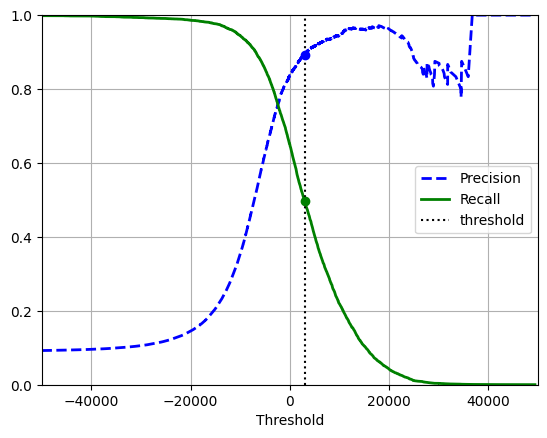

In [17]:
from sklearn.metrics import precision_recall_curve

threshold = 3000

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")

idx = (thresholds >= threshold).argmax()
plt.plot(thresholds[idx], precisions[idx], "bo")
plt.plot(thresholds[idx], recalls[idx], "go")
plt.axis([-50000, 50000, 0, 1])
plt.grid()
plt.xlabel("Threshold")
plt.legend(loc="center right")

plt.show()

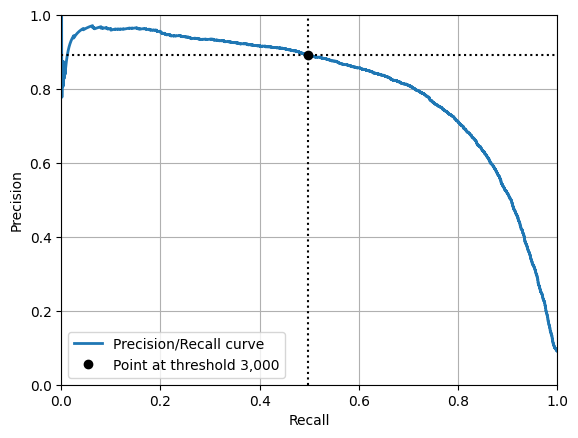

In [ ]:
# plotting precision vs recall
plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")

plt.axis([0, 1, 0, 1])
plt.plot([recalls[idx]], [precisions[idx]], "ko", label="Point at threshold 3,000")
plt.vlines(recalls[idx], 0, 1.0, "k", "dotted")
plt.hlines(precisions[idx], 0, 1.0, "k", "dotted")
plt.grid()
plt.ylabel("Precision")

plt.xlabel("Recall")
plt.legend(loc="lower left")

In [19]:
idx_for_90p = (precisions >= 0.90).argmax()
threshold_for_90p = thresholds[idx_for_90p]
threshold_for_90p

np.float64(3370.0194991439557)

In [ ]:
y_train_pred5_90 = y_scores >= threshold_for_90p

precision_score(y_train_5, y_train_pred5_90)
recall_score(y_train_5, y_train_pred5_90)

0.4799852425751706

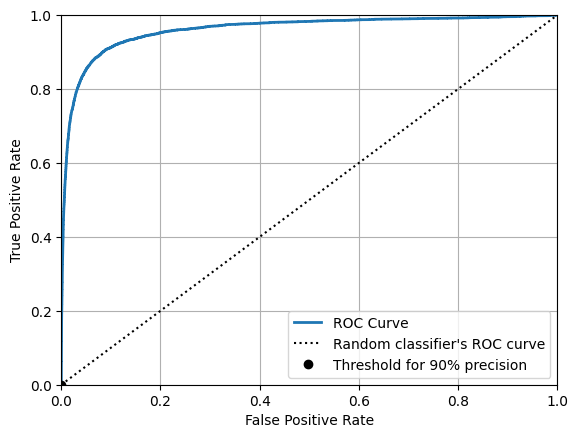

In [21]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, threshold = roc_curve(y_train_5, y_scores)

idx_for_threshold_at_90 = (thresholds <= threshold_for_90p).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

plt.plot(fpr, tpr, linewidth=2, label="ROC Curve")
plt.plot([0, 1], [0, 1], "k:", label="Random classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")

plt.axis([0, 1, 0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid()
plt.legend(loc="lower right")
plt.show()

In [22]:
roc_auc_score(y_train_5, y_scores)

0.9604938554008616

In [ ]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state=42)
y_probas_forest = cross_val_predict(
    forest_clf, X_train, y_train_5, cv=3, method="predict_proba"
)

In [ ]:
y_scores_forest = y_probas_forest[:, 1]
precisions_f, recalls_f, thresholds_f = precision_recall_curve(
    y_train_5, y_scores_forest
)


def plot_PRC(precisions, recalls, thresholds):

    plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")
    plt.axis([0, 1, 0, 1])
    plt.ylabel("Precision")
    plt.xlabel("Recall")
    plt.legend(loc="lower left")


def plot_ROC(fpr, tpr):

    plt.plot(fpr, tpr, linewidth=2, label="ROC Curve")
    plt.plot([0, 1], [0, 1], "k:", label="Random classifier's ROC curve")

    plt.axis([0, 1, 0, 1])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid()
    plt.legend(loc="lower right")

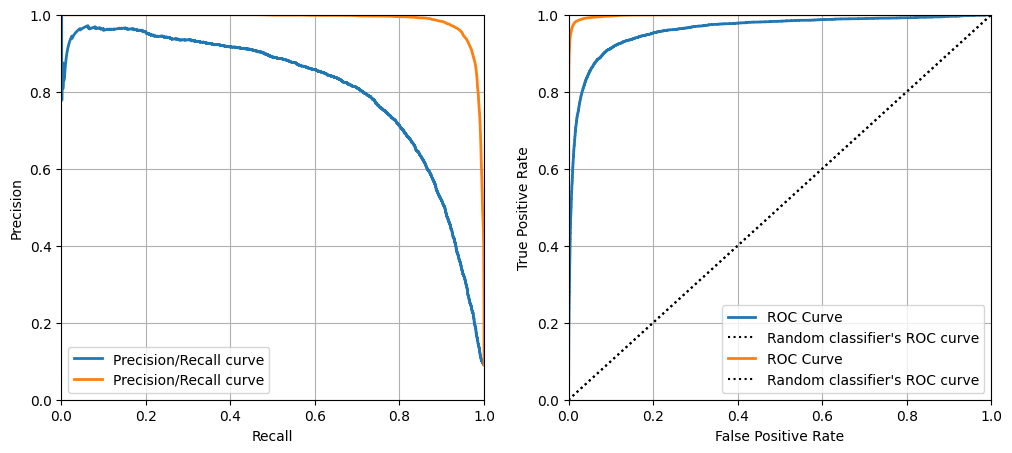

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_PRC(precisions, recalls, thresholds)
plot_PRC(precisions_f, recalls_f, thresholds_f)
plt.grid()

fpr_f, tpr_f, threshold = roc_curve(y_train_5, y_scores_forest)

plt.subplot(1, 2, 2)
plot_ROC(fpr, tpr)
plot_ROC(fpr_f, tpr_f)
plt.grid()

<h1>Multi-Class Classification</h1>


In [26]:
from sklearn.svm import SVC

svm_clf = SVC(random_state=42)
svm_clf.fit(X_train[:2000], y_train[:2000])

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype("float64"))

In [ ]:
cross_val_score(
    svm_clf, X_train_scaled[:2000], y_train[:2000], cv=3, scoring="accuracy"
)

array([0.88155922, 0.86206897, 0.91291291])

In [30]:
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [ ]:
import os
import joblib

filename = 'y_train_pred_scaled.pkl'

if (os.path.exists(filename)):
    y_train_pred = joblib.load(filename)
    print("Loaded sgd predictions from memory")
else:
    print("Computing sgd preditictions ~17min")
    y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)
    joblib.dump(y_train_pred, filename)


Loaded sgd predictions from memory


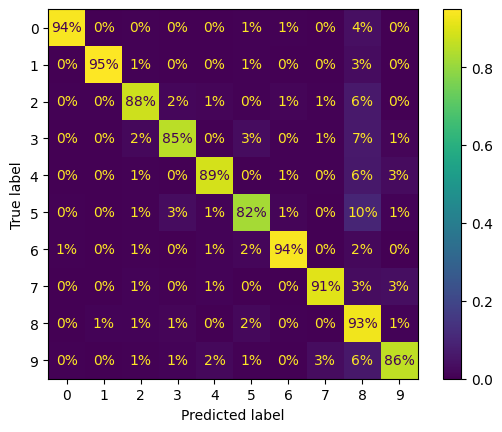

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_train, y_train_pred, normalize="true", values_format=".0%"
)
plt.show()

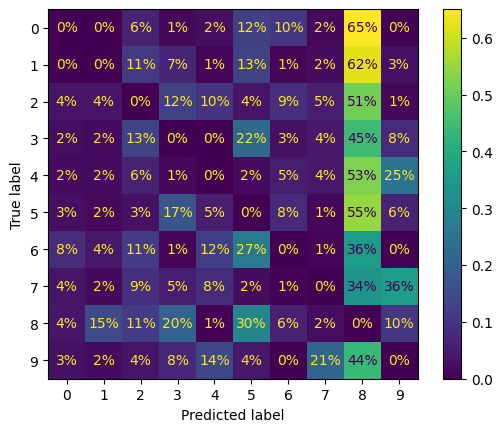

In [38]:
sample_weight = (y_train_pred != y_train)
ConfusionMatrixDisplay.from_predictions(
    y_train,
    y_train_pred,
    sample_weight=sample_weight,
    normalize="true",
    values_format=".0%",
)
plt.show()

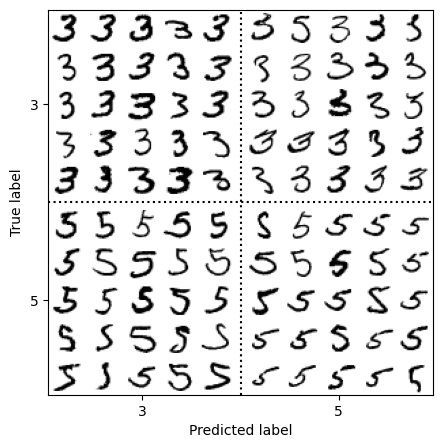

In [42]:
cl_a, cl_b = '3', '5'
X_aa = X_train[(y_train == cl_a) & (y_train_pred == cl_a)]
X_ab = X_train[(y_train == cl_a) & (y_train_pred == cl_b)]
X_ba = X_train[(y_train == cl_b) & (y_train_pred == cl_a)]
X_bb = X_train[(y_train == cl_b) & (y_train_pred == cl_b)]

# extra code – this cell generates Figure 3–11
size = 5
pad = 0.2
plt.figure(figsize=(size, size))
for images, (label_col, label_row) in [(X_ba, (0, 0)), (X_bb, (1, 0)),
                                       (X_aa, (0, 1)), (X_ab, (1, 1))]:
    for idx, image_data in enumerate(images[:size*size]):
        x = idx % size + label_col * (size + pad)
        y = idx // size + label_row * (size + pad)
        plt.imshow(image_data.reshape(28, 28), cmap="binary",
                   extent=(x, x + 1, y, y + 1))
        
plt.xticks([size / 2, size + pad + size / 2], [str(cl_a), str(cl_b)])
plt.yticks([size / 2, size + pad + size / 2], [str(cl_b), str(cl_a)])
plt.plot([size + pad / 2, size + pad / 2], [0, 2 * size + pad], "k:")
plt.plot([0, 2 * size + pad], [size + pad / 2, size + pad / 2], "k:")
plt.axis([0, 2 * size + pad, 0, 2 * size + pad])
plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.show()